In [5]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# CELL 1: Khai báo thư viện và Gộp bộ dữ liệu (2022 - 2025)
# Bước này giúp ta đọc cả 4 file .csv,
# Đồng bộ hóa tên cột (vì file 2022 ghi là Country Code còn các file khác ghi Country code, tương tự với Timezone), 
# Ép kiểu dữ liệu thời gian và xử lý dữ liệu khuyết thiếu.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Cấu hình biểu đồ hiển thị tiếng Việt/đẹp mắt hơn
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Đọc và làm sạch dữ liệu từng năm
files = ['../datasets/2022.csv', '../datasets/2023.csv', '../datasets/2024.csv', '../datasets/2025.csv']
df_list = []

for file in files:
    df_temp = pd.read_csv(file)
    # Đồng bộ viết hoa/thường của tên cột để gộp không bị lỗi
    df_temp.columns = df_temp.columns.str.strip().str.title()
    df_list.append(df_temp)

# Gộp dữ liệu
df = pd.concat(df_list, ignore_index=True)

# 2. Xử lý định dạng thời gian
df['Local Time'] = pd.to_datetime(df['Local Time'])
df = df.sort_values('Local Time').reset_index(drop=True)

# 3. Trích xuất các đặc trưng thời gian phục vụ phân tích
df['Year'] = df['Local Time'].dt.year
df['Month'] = df['Local Time'].dt.month
df['Hour'] = df['Local Time'].dt.hour
df['DayOfWeek'] = df['Local Time'].dt.dayofweek # 0: Thứ 2, ..., 6: Chủ Nhật
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 'Cuối tuần' if x >= 5 else 'Ngày thường')

# 4. Xử lý giá trị trống (Missing values) bằng giá trị trung vị
features_to_impute = ['Aqi', 'Co', 'No2', 'O3', 'Pm10', 'Pm25', 'So2', 'Temperature', 'Relative Humidity', 'Wind Speed']
for col in features_to_impute:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print("------Thông tin tổng quan bộ dữ liệu sau khi gộp------")
df.info()

------Thông tin tổng quan bộ dữ liệu sau khi gộp------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30341 entries, 0 to 30340
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Local Time         30341 non-null  datetime64[ns]
 1   Utc Time           30341 non-null  object        
 2   City               30341 non-null  object        
 3   Country Code       30341 non-null  object        
 4   Timezone           30341 non-null  object        
 5   Aqi                30341 non-null  float64       
 6   Co                 30341 non-null  float64       
 7   No2                30341 non-null  float64       
 8   O3                 30341 non-null  float64       
 9   Pm10               30341 non-null  float64       
 10  Pm25               30341 non-null  float64       
 11  So2                30341 non-null  float64       
 12  Clouds             30341 non-null  int64         
 13  Precip

--- AQI Trung bình tổng thể qua các năm ---
 Year        Aqi
 2022 119.149551
 2023 123.219895
 2024 119.894857
 2025 141.859379

--- AQI Trung bình Cùng Kỳ (6 Tháng Đầu Năm) ---
 Year        Aqi
 2022 125.827909
 2023 125.337247
 2024 120.691533
 2025 141.859379


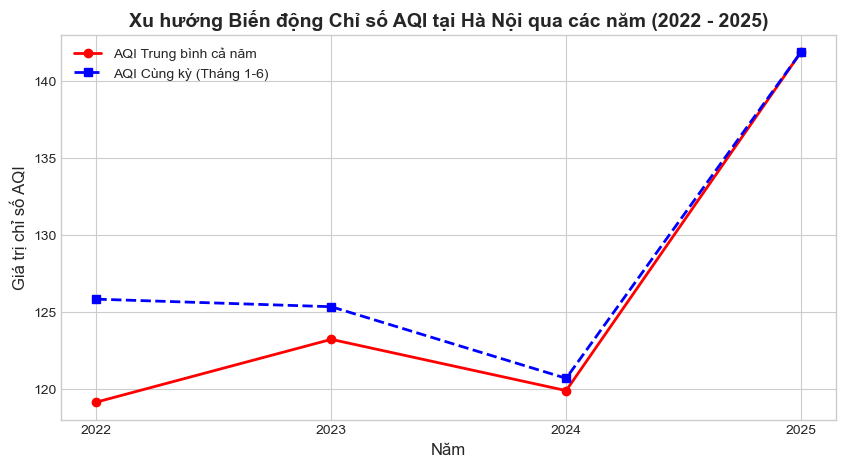

In [3]:
# CELL 2: Câu 1 - Chất lượng không khí tổng thể của Hà Nội trong giai đoạn 2022 - 2025 có xu hướng cải thiện hay ngày càng nghiêm trọng hơn qua các năm?
# Lưu ý: Năm 2025 dữ liệu chỉ có đến tháng 6 nên giá trị trung bình sẽ mang tính đại diện cho nửa đầu năm

# Tính AQI trung bình toàn vẹn
yearly_aqi = df.groupby('Year')['Aqi'].mean().reset_index()

# Tính AQI trung bình cùng kỳ 6 tháng đầu năm để khử Bias cho năm 2025
h1_df = df[df['Month'] <= 6]
yearly_aqi_h1 = h1_df.groupby('Year')['Aqi'].mean().reset_index()

print("--- AQI Trung bình tổng thể qua các năm ---")
print(yearly_aqi.to_string(index=False))
print("\n--- AQI Trung bình Cùng Kỳ (6 Tháng Đầu Năm) ---")
print(yearly_aqi_h1.to_string(index=False))

# Trực quan hóa xu hướng dài hạn
plt.figure(figsize=(10, 5))
plt.plot(yearly_aqi['Year'].astype(str), yearly_aqi['Aqi'], marker='o', color='red', linewidth=2, label='AQI Trung bình cả năm')
plt.plot(yearly_aqi_h1['Year'].astype(str), yearly_aqi_h1['Aqi'], marker='s', color='blue', linestyle='--', linewidth=2, label='AQI Cùng kỳ (Tháng 1-6)')
plt.title('Xu hướng Biến động Chỉ số AQI tại Hà Nội qua các năm (2022 - 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Giá trị chỉ số AQI', fontsize=12)
plt.legend()
plt.show()

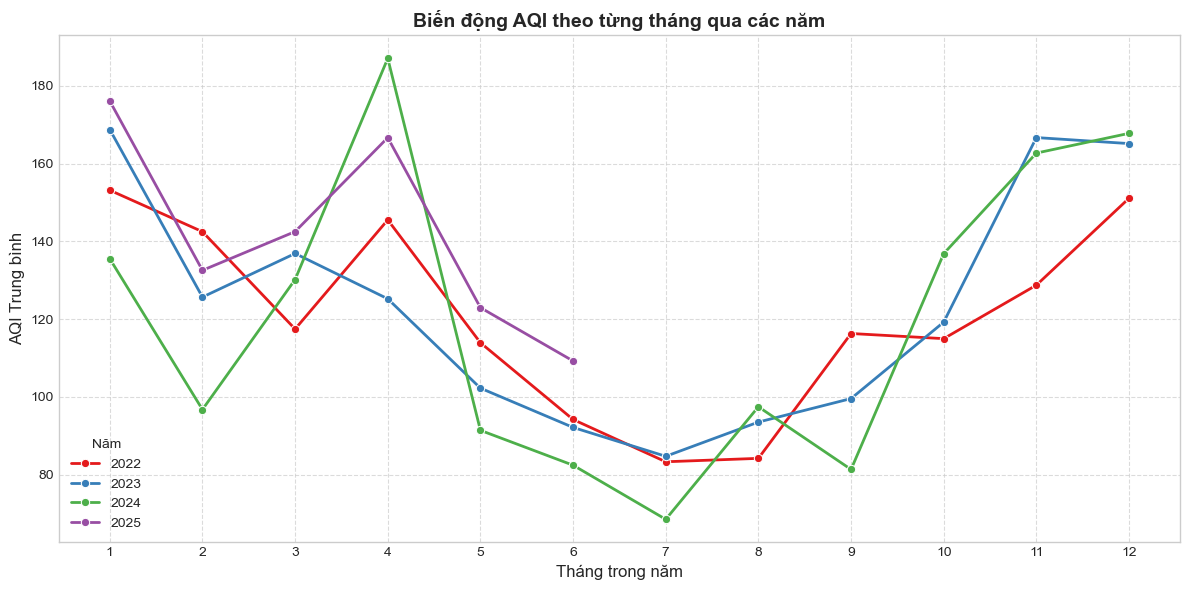

In [11]:
# CELL 3: Câu 2 - Mùa nào trong năm có mức ô nhiễm không khí cao nhất?

# Tính toán AQI trung bình theo Năm và Tháng
monthly_yearly_aqi = df.groupby(['Year', 'Month'])['Aqi'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_yearly_aqi, x='Month', y='Aqi', hue='Year', marker='o', palette='Set1', linewidth=2)

plt.title('Biến động AQI theo từng tháng qua các năm', fontsize=14, fontweight='bold')
plt.xlabel('Tháng trong năm', fontsize=12)
plt.ylabel('AQI Trung bình', fontsize=12)
plt.xticks(range(1, 13))
plt.legend(title='Năm')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

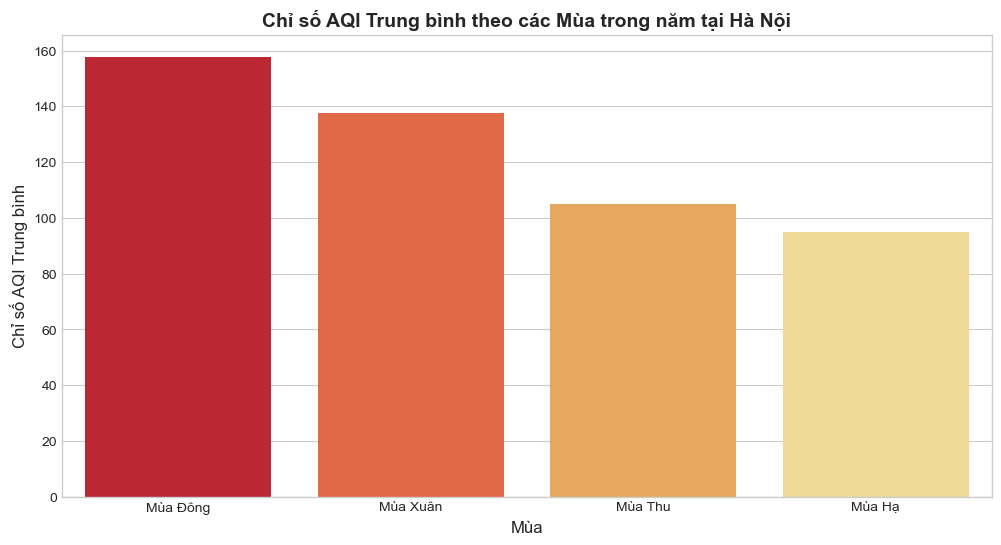

In [8]:
def get_season(month):
    if month in [2, 3, 4]: return 'Mùa Xuân'
    elif month in [5, 6, 7]: return 'Mùa Hạ'
    elif month in [8, 9, 10]: return 'Mùa Thu'
    else: return 'Mùa Đông'

df['Season'] = df['Month'].apply(get_season)
season_aqi = df.groupby('Season')['Aqi'].mean().reset_index().sort_values(by='Aqi', ascending=False)

# Trực quan hóa mức độ ô nhiễm theo mùa
sns.barplot(data=season_aqi, x='Season', y='Aqi', palette='YlOrRd_r')
plt.title('Chỉ số AQI Trung bình theo các Mùa trong năm tại Hà Nội', fontsize=14, fontweight='bold')
plt.xlabel('Mùa', fontsize=12)
plt.ylabel('Chỉ số AQI Trung bình', fontsize=12)
plt.show()

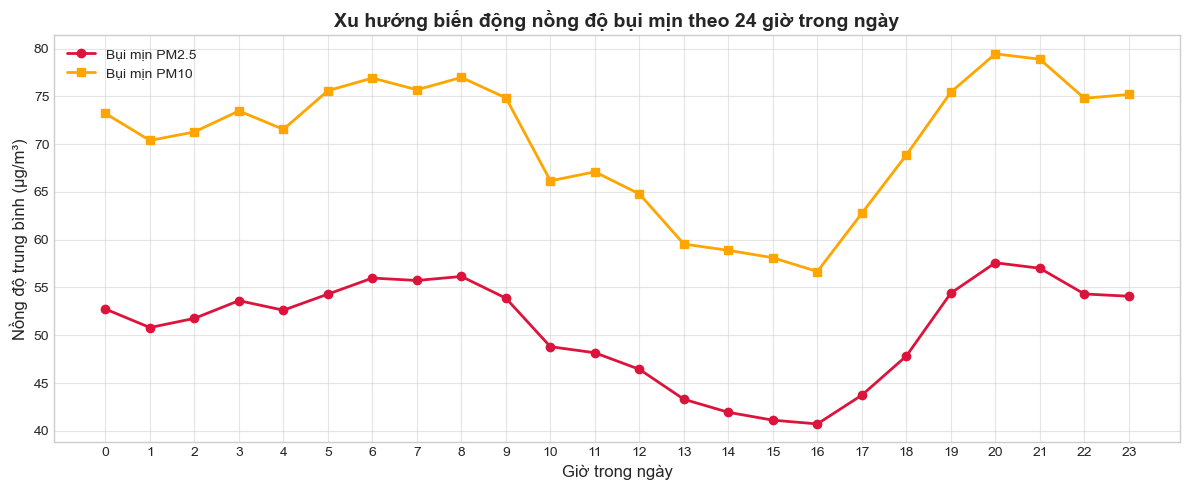

In [12]:
# CELL 4: Câu 3 - Trong một ngày, chỉ số bụi mịn thường đạt đỉnh vào những khung giờ nào?

# Tính giá trị trung bình của bụi mịn theo từng giờ trong ngày
hourly_pollution = df.groupby('Hour')[['Pm25', 'Pm10']].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(hourly_pollution['Hour'], hourly_pollution['Pm25'], label='Bụi mịn PM2.5', marker='o', color='crimson', linewidth=2)
plt.plot(hourly_pollution['Hour'], hourly_pollution['Pm10'], label='Bụi mịn PM10', marker='s', color='orange', linewidth=2)

plt.title('Xu hướng biến động nồng độ bụi mịn theo 24 giờ trong ngày', fontsize=14, fontweight='bold')
plt.xlabel('Giờ trong ngày', fontsize=12)
plt.ylabel('Nồng độ trung bình (µg/m³)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

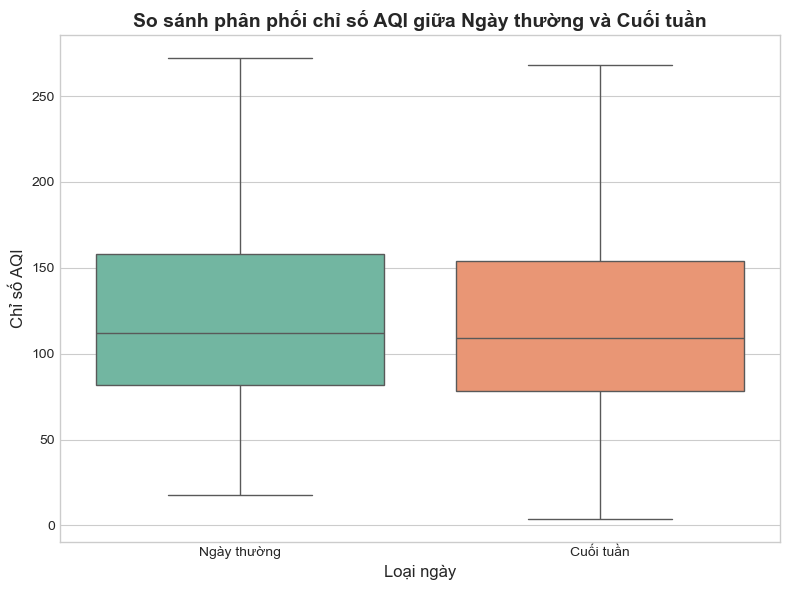

KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ (T-TEST):
- T-statistic: 3.1039
- P-value: 0.0019
=> Kết luận: Có sự khác biệt về AQI giữa ngày thường và cuối tuần.
   AQI trung bình Ngày thường: 124.47 | Cuối tuần: 122.10


In [21]:
# CELL 5: Câu 4 - So sánh AQI ngày thường và cuối tuần

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='IsWeekend', y='Aqi', palette='Set2', showfliers=False) # Ẩn outliers để dễ nhìn phân phối chính
plt.title('So sánh phân phối chỉ số AQI giữa Ngày thường và Cuối tuần', fontsize=14, fontweight='bold')
plt.xlabel('Loại ngày', fontsize=12)
plt.ylabel('Chỉ số AQI', fontsize=12)
plt.tight_layout()
plt.show()

# Kiểm định giả thuyết T-test độc lập
weekday_aqi = df[df['IsWeekend'] == 'Ngày thường']['Aqi']
weekend_aqi = df[df['IsWeekend'] == 'Cuối tuần']['Aqi']

t_stat, p_val = stats.ttest_ind(weekday_aqi, weekend_aqi, equal_var=False)

print("KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ (T-TEST):")
print(f"- T-statistic: {t_stat:.4f}")
print(f"- P-value: {p_val:.4f}")

if p_val < 0.05:
    print("=> Kết luận: Có sự khác biệt về AQI giữa ngày thường và cuối tuần.")
    print(f"   AQI trung bình Ngày thường: {weekday_aqi.mean():.2f} | Cuối tuần: {weekend_aqi.mean():.2f}")
else:
    print("=> Kết luận: KHÔNG có sự khác biệt ý nghĩa thống kê về AQI giữa ngày thường và cuối tuần.")

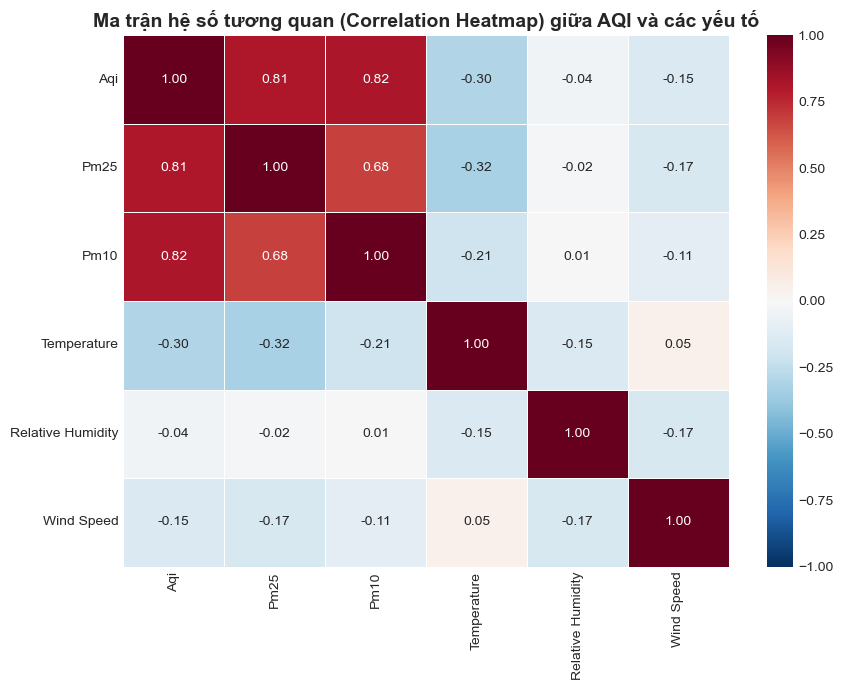

In [22]:
# CELL 6: Câu 5 - Mối quan hệ giữa AQI và các yếu tố môi trường như thế nào?
# Sử dụng Ma trận nhiệt tương quan để định lượng mối quan hệ tuyến tính giữa các biến.

# Chọn các cột cần tính tương quan
corr_features = ['Aqi', 'Pm25', 'Pm10', 'Temperature', 'Relative Humidity', 'Wind Speed']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Ma trận hệ số tương quan (Correlation Heatmap) giữa AQI và các yếu tố', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

KẾT QUẢ DỰ BÁO CHUỖI THỜI GIAN:
- Ngày cuối cùng ghi nhận trong tập dữ liệu: 2025-06-30
- Dự báo chỉ số AQI TRUNG BÌNH cho ngày tiếp theo (2025-07-01): 99.37


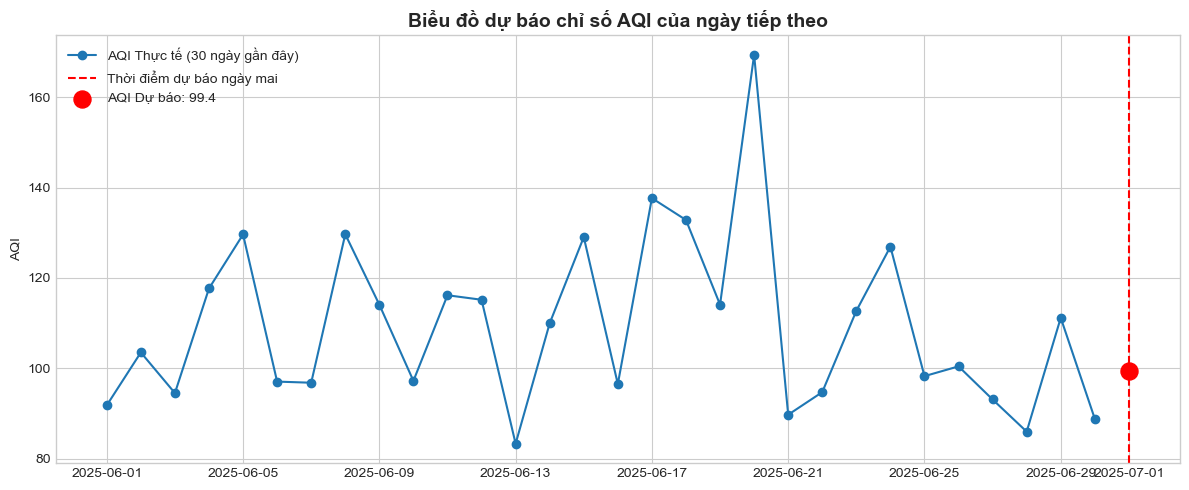

In [23]:
# CELL 7: Dự báo chỉ số AQI của ngày mai tại Hà Nội sẽ là bao nhiêu?
# Vì dữ liệu gốc là theo giờ (Hourly), để dự báo AQI của ngày mai, 
# Trước hết ta cần resample dữ liệu về theo chuỗi ngày (Daily Mean), sau đó áp dụng mô hình chuỗi thời gian.

# 1. Chuyển đổi dữ liệu từ theo giờ thành dữ liệu trung bình theo ngày
daily_df = df.set_index('Local Time').resample('D')['Aqi'].mean().to_frame()
# Xử lý nếu có ngày bị khuyết thiếu dữ liệu do resample bằng phương pháp nội suy linear
daily_df['Aqi'] = daily_df['Aqi'].interpolate(method='linear')

# 2. Xây dựng mô hình SARIMAX (Cấu hình cơ bản, có tính tuần hoàn 7 ngày)
model = SARIMAX(daily_df['Aqi'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
model_fitted = model.fit(disp=False)

# 3. Tiến hành dự báo cho ngày tiếp theo
forecast = model_fitted.forecast(steps=1)
forecast_date = forecast.index[0].strftime('%Y-%m-%d')
forecast_value = forecast.values[0]

print("KẾT QUẢ DỰ BÁO CHUỖI THỜI GIAN:")
print(f"- Ngày cuối cùng ghi nhận trong tập dữ liệu: {daily_df.index[-1].strftime('%Y-%m-%d')}")
print(f"- Dự báo chỉ số AQI TRUNG BÌNH cho ngày tiếp theo ({forecast_date}): {forecast_value:.2f}")

# Trực quan hóa 30 ngày cuối cùng và ngày dự báo
plt.figure(figsize=(12, 5))
plt.plot(daily_df.index[-30:], daily_df['Aqi'].tail(30), label='AQI Thực tế (30 ngày gần đây)', marker='o')
plt.axvline(x=forecast.index[0], color='red', linestyle='--', label='Thời điểm dự báo ngày mai')
plt.scatter(forecast.index, [forecast_value], color='red', s=150, zorder=5, label=f'AQI Dự báo: {forecast_value:.1f}')
plt.title('Biểu đồ dự báo chỉ số AQI của ngày tiếp theo', fontsize=14, fontweight='bold')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.show()

BẢNG KẾT QUẢ PHÂN CỤM 12 THÁNG TẠI HÀ NỘI:
 Month        Aqi      Pm25                       Tên Cụm
     1 158.938616 73.947545        Mùa ô nhiễm cao điểm 🚨
     2 124.129056 50.889720        Mùa ô nhiễm cao điểm 🚨
     3 131.759154 53.186537        Mùa ô nhiễm cao điểm 🚨
     4 156.124262 59.662086        Mùa ô nhiễm cao điểm 🚨
     5 107.654686 40.365778 Mùa ô nhiễm thấp/trung bình 🌱
     6  94.524306 33.129774 Mùa ô nhiễm thấp/trung bình 🌱
     7  78.877688 24.643786 Mùa ô nhiễm thấp/trung bình 🌱
     8  91.749104 30.357419 Mùa ô nhiễm thấp/trung bình 🌱
     9  99.089352 34.335699 Mùa ô nhiễm thấp/trung bình 🌱
    10 123.693548 48.993754 Mùa ô nhiễm thấp/trung bình 🌱
    11 152.715410 81.408473        Mùa ô nhiễm cao điểm 🚨
    12 161.295156 78.676949        Mùa ô nhiễm cao điểm 🚨


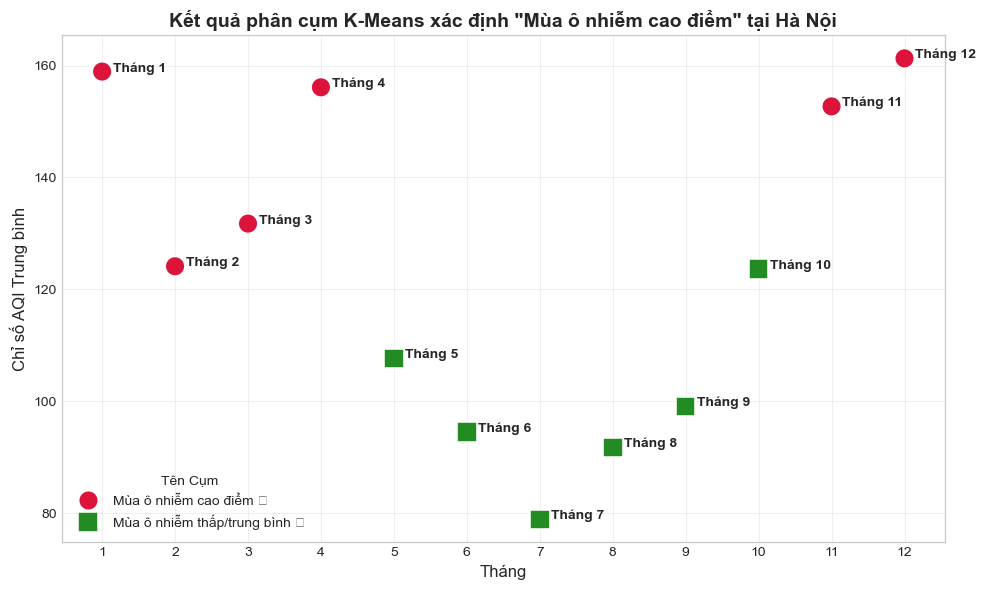

In [24]:
# CELL 8: Phân cụm các tháng trong giai đoạn 2022-2025 để xác định "Mùa ô nhiễm cao điểm"
# Để phân cụm các tháng một cách khách quan, ta sẽ gom nhóm dựa trên hồ sơ ô nhiễm của tháng đó 
# (AQI trung bình, tỷ lệ bụi mịn PM2.5, PM10 trung bình qua các năm).

# 1. Chuẩn bị dữ liệu đặc trưng cho từng tháng (từ tháng 1 đến tháng 12)
# Tính giá trị trung bình tổng thể của từng tháng qua các năm
month_features = df.groupby('Month')[['Aqi', 'Pm25', 'Pm10', 'Temperature']].mean().reset_index()

# 2. Chuẩn hóa dữ liệu (Feature Scaling) vì K-means nhạy cảm với khoảng cách đại lượng
scaler = StandardScaler()
X_scaled = scaler.fit_transform(month_features[['Aqi', 'Pm25', 'Pm10', 'Temperature']])

# 3. Tiến hành phân cụm K-Means (Chọn K=2 cụm: Ô nhiễm cao điểm vs Ô nhiễm thấp/Trung bình)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
month_features['Cluster'] = kmeans.fit_predict(X_scaled)

# Xác định xem cụm nào là cụm "Ô nhiễm cao điểm" bằng cách xem cụm nào có AQI trung bình cao hơn
cluster_means = month_features.groupby('Cluster')['Aqi'].mean()
high_pollution_cluster = cluster_means.idxmax()

# Thêm nhãn tường minh
month_features['Tên Cụm'] = month_features['Cluster'].apply(
    lambda x: 'Mùa ô nhiễm cao điểm 🚨' if x == high_pollution_cluster else 'Mùa ô nhiễm thấp/trung bình 🌱'
)

# 4. Xuất kết quả bảng phân cụm rõ ràng
print("BẢNG KẾT QUẢ PHÂN CỤM 12 THÁNG TẠI HÀ NỘI:")
print(month_features[['Month', 'Aqi', 'Pm25', 'Tên Cụm']].sort_values(by='Month').to_string(index=False))

# 5. Trực quan hóa kết quả phân cụm bằng Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=month_features, x='Month', y='Aqi', hue='Tên Cụm', 
    palette={ 'Mùa ô nhiễm cao điểm 🚨': 'crimson', 'Mùa ô nhiễm thấp/trung bình 🌱': 'forestgreen' },
    s=200, style='Tên Cụm', markers=['o', 's']
)

# Ghi chú tên tháng
for i, row in month_features.iterrows():
    plt.text(row['Month'] + 0.15, row['Aqi'], f"Tháng {int(row['Month'])}", fontsize=10, fontweight='bold')

plt.title('Kết quả phân cụm K-Means xác định "Mùa ô nhiễm cao điểm" tại Hà Nội', fontsize=14, fontweight='bold')
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Chỉ số AQI Trung bình', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()